In [46]:
import statsmodels as sm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.main import get_data

In [47]:
def fft_denoise(x, keep_fraction=0.1):
    """
    keep_fraction: fraction of low frequencies to keep
    """
    x = np.asarray(x)
    
    X = np.fft.rfft(x)
    
    n = len(X)
    k = int(n * keep_fraction)
    
    # keep low frequencies, kill high frequencies
    X_filtered = np.zeros_like(X)
    X_filtered[:k] = X[:k]
    
    x_clean = np.fft.irfft(X_filtered, n=len(x))
    
    return x_clean

In [48]:
from src.indicators import calc_adx, calc_log_rt, calc_rvol

data = get_data(["AA"], "2017-01-01", "2026-06-01")

data.columns = data.columns.droplevel(1)

close = data["Close"]



[*********************100%***********************]  1 of 1 completed


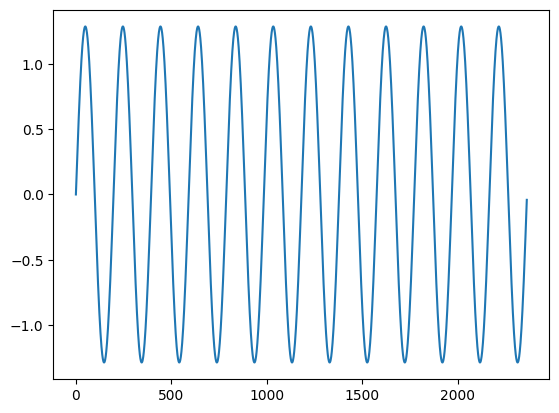

In [49]:
x = np.asarray(close)
N = len(x)

X = np.fft.rfft(x)
freqs = np.fft.rfftfreq(N, d=1)   # d = sample spacing (1.0 = per-sample)

bin_idx = 12
f = freqs[bin_idx]                  # real frequency for that bin
amp = np.abs(X[bin_idx]) / N        # optional: amplitude of that component

t = np.arange(0, N)                 # sample indices
plt.plot(t, amp * np.sin(2*np.pi*f*t))
plt.show()

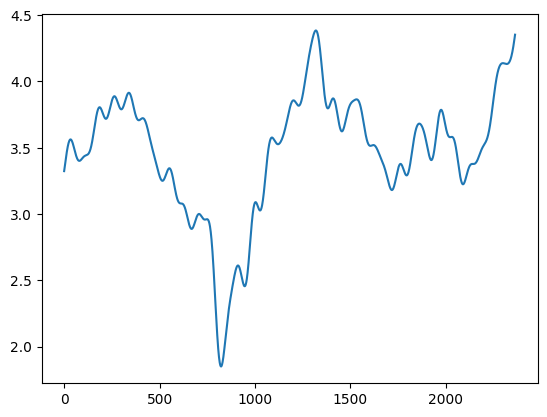

In [50]:
log_return = calc_log_rt(close).dropna()

clean_returns = fft_denoise(log_return.values, keep_fraction=0.03)

plt.plot(np.log(close.iloc[0]) + np.cumsum(clean_returns))
plt.show()


In [51]:
window_size = 30
step_size = 5

windows = []
segments = []

n = len(log_return)

for start in range(0, n, step_size):
    end = start + window_size

    if end > n:
        end = n

    windows.append((start, end))
    segments.append(log_return[start:end])

In [52]:
from scipy.stats import wasserstein_distance

n_segments = len(segments)
distance_matrix = np.zeros((n_segments, n_segments))

for i in range(n_segments):
    for j in range(i + 1, n_segments):
        dist = wasserstein_distance(segments[i], segments[j])
        distance_matrix[i, j] = dist
        distance_matrix[j, i] = dist

(473, 473)


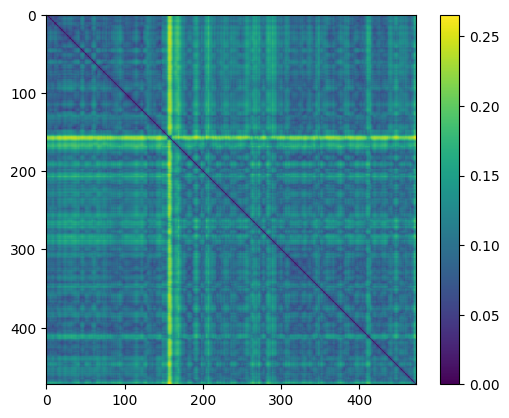

In [53]:
print(distance_matrix.shape)
plt.imshow(np.sqrt(distance_matrix), cmap="viridis")
plt.colorbar()
plt.show()

In [54]:
from sklearn.manifold import MDS

mds = MDS(n_components=6, metric='precomputed', random_state=42, n_init=4)
embedding = mds.fit_transform(distance_matrix)


c:\Users\tothk\Documents\Python\finance\.venv\Lib\site-packages\sklearn\manifold\_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


In [55]:
from sklearn.cluster import KMeans

n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(embedding)

n_regimes = n_clusters

votes = np.zeros((len(log_return), n_clusters))
counts = np.zeros(len(log_return))

for (start, end), label in zip(windows, labels):
    votes[start:end, label] += 1
    counts[start:end] += 1

    
    
probs = np.full_like(votes, np.nan, dtype=float)

mask = counts > 0
probs[mask] = votes[mask] / counts[mask, None]

In [56]:
print("min counts:", counts.min())
print("max counts:", counts.max())
print("zero coverage points:", np.sum(counts == 0))

min counts: 1.0
max counts: 6.0
zero coverage points: 0


In [57]:
probs[-970:]

array([[0.66666667, 0.16666667, 0.16666667],
       [0.66666667, 0.16666667, 0.16666667],
       [0.83333333, 0.16666667, 0.        ],
       ...,
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ],
       [1.        , 0.        , 0.        ]], shape=(970, 3))

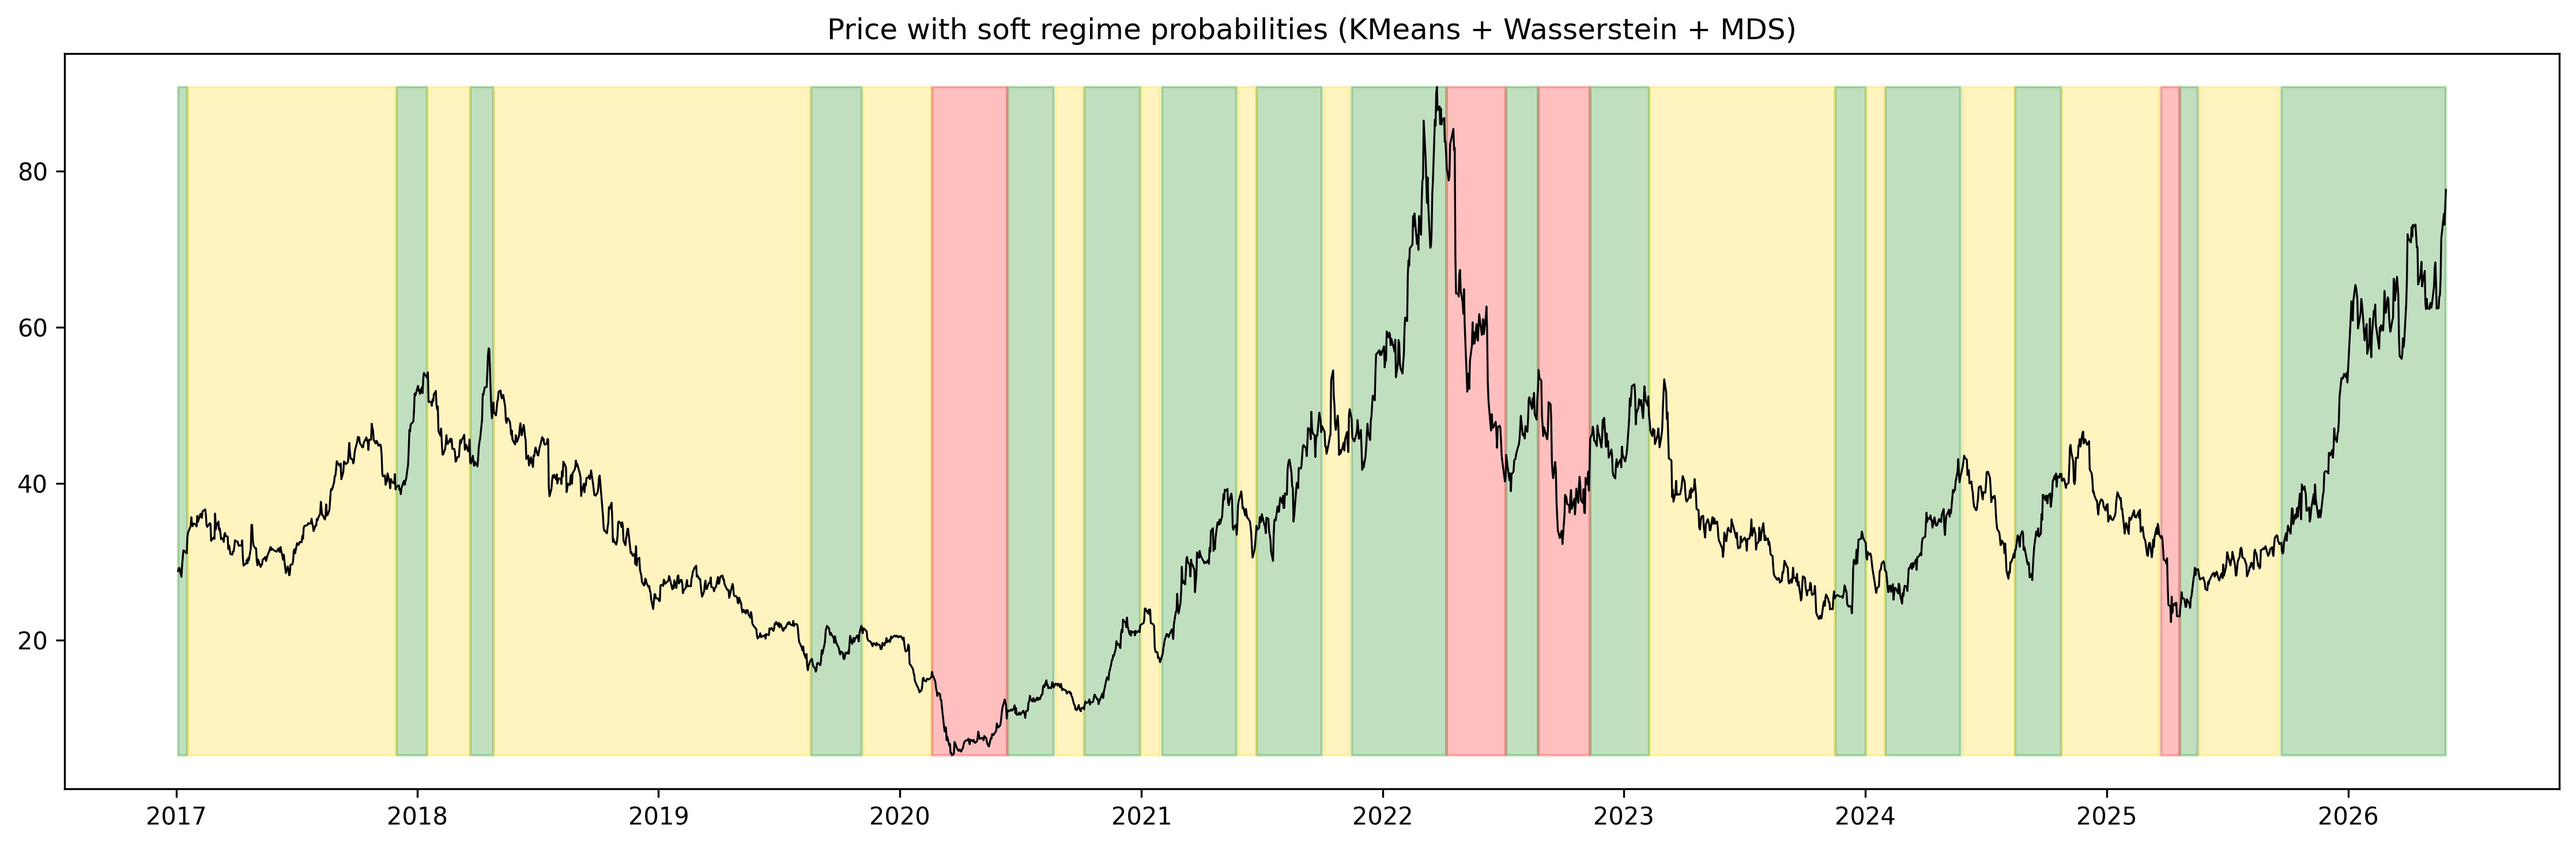

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

base_index = log_return.index
price = close.loc[base_index]

# --- convert to DataFrame for convenience ---
probs_df = pd.DataFrame(probs, index=base_index).ffill().fillna(0)

# --- plotting ---
fig, ax = plt.subplots(figsize=(15, 5), dpi=300)

ax.plot(price.index, price.values, color="black", lw=0.8)

# colormap (same as yours)
ramp = mcolors.LinearSegmentedColormap.from_list(
    "regime", ["green", "gold", "red"]
)

palette = [
    ramp(i / (n_clusters - 1))
    for i in range(n_clusters)
]

# --- soft shading per regime ---
for r in range(n_clusters):
    ax.fill_between(
        price.index,
        price.min(),
        price.max(),
        where=probs_df.values.argmax(axis=1) == r,
        color=palette[r],
        alpha=0.25,  # <- key change
        step="mid"
    )

ax.set_title("Price with soft regime probabilities (KMeans + Wasserstein + MDS)")
plt.tight_layout()
plt.show()